In [ ]:
Also add static soil variables?

In [2]:
"""
Diagnostic script: soil moisture -> volumetric saturation -> Fu/IMD (m)
for ONE catchment (HA_NUM) and ONE ensemble member.

Adapted from the main FUTURE-FLOOD soil pipeline for notebook-style
inspection: no multiprocessing, no argparse, intermediate arrays kept
in memory so you can look at them directly.
"""

import glob
import os
import re
from tqdm import tqdm

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import rioxarray  # noqa: F401  (registers .rio accessor)
import xarray as xr
import matplotlib.pyplot as plt
from rasterio.warp import Resampling, reproject
from shapely.geometry import box

# --------------------------
# Configuration — edit these
# --------------------------
CRS_TARGET = "EPSG:27700"

DEM_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem/"
CSV_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/"
NETCDF_DIR = "/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/"
SOIL_TEXTURE_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
POROSITY_CSV = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/SoilTexture/USDA_soil_texture_effective_porosity.csv"
SOILS_LOOKUP_CSV = "../../Data/Rawls_soil_lookup.csv"  # USDA_soil, Hydraulic_conductivity


In [3]:
# --------------------------
# Helper functions (copied from the main pipeline script)
# --------------------------
def extract_ha_num(path_or_name):
    """Extract an HA identifier such as 27, 27_a, or 54_d."""
    base = os.path.splitext(os.path.basename(path_or_name))[0]
    match = re.search(r"(\d+(?:_[A-Za-z0-9]+)?)$", base)
    return match.group(1) if match else None


def find_matching_netcdf(netcdf_dir, year, month, day):
    """Return the NetCDF whose date range contains the event date."""
    target_date_int = int(f"{year:04d}{month:02d}{day:02d}")
    for nc_file in glob.glob(os.path.join(netcdf_dir, "*.nc")):
        match = re.search(r"_(\d{8})-(\d{8})_", os.path.basename(nc_file))
        if match and int(match.group(1)) <= target_date_int <= int(match.group(2)):
            return nc_file
    print(f"[NetCDF Search Fail] No match for date {target_date_int} in {netcdf_dir}")
    return None


def clip_gravitational(ds, var, bounds):
    """Clip gravitational soil-moisture data in memory."""
    if not ds.rio.crs:
        ds = ds.rio.write_crs(CRS_TARGET)
    return ds[var].rio.clip_box(
        minx=bounds.bounds[0],
        miny=bounds.bounds[1],
        maxx=bounds.bounds[2],
        maxy=bounds.bounds[3],
    )


def resample_to_30m_array(source_data, dem):
    """Resample clipped gravitational (or other) data to the DEM grid."""
    source_array = np.squeeze(source_data.values)
    if source_array.ndim != 2:
        raise ValueError(f"Expected a 2D array, got {source_array.shape}")

    resampled = np.empty((dem["height"], dem["width"]), dtype=source_array.dtype)
    reproject(
        source=source_array,
        destination=resampled,
        src_transform=source_data.rio.transform(),
        src_crs=source_data.rio.crs,
        dst_transform=dem["transform"],
        dst_crs=dem["crs"],
        resampling=Resampling.nearest,
    )
    return resampled


def load_soil_grids(porosity_csv, soils_lookup_csv, soil_texture_dir, target_has):
    """Load porosity and effective depth (Lu) grids together, one soil-texture
    raster read per catchment, so both grids are guaranteed pixel-aligned.

    Lu[m] = 0.06375 * sqrt(Ks[cm/hr])  (Green-Ampt Lu = 4*sqrt(Ks), unit-converted)
    """
    porosity_df = pd.read_csv(porosity_csv)
    porosity_map = porosity_df.set_index("USDA_soil")["Effective_porosity"].to_dict()

    hc_df = pd.read_csv(soils_lookup_csv)
    hc_map = hc_df.set_index("USDA_soil")["Hydraulic_conductivity"].to_dict()

    soil_grids = {}
    for tif in glob.glob(os.path.join(soil_texture_dir, "*.tif")):
        ha_num = extract_ha_num(tif)
        if ha_num is None or ha_num not in target_has:
            continue

        with rasterio.open(tif) as src:
            data = src.read(1)
            valid = data != src.nodata

            porosity = np.vectorize(lambda v: porosity_map.get(v, np.nan))(data)
            porosity[~valid] = np.nan

            hc_values = np.vectorize(lambda v: hc_map.get(v, np.nan))(data)
            hc_values[~valid] = np.nan
            lu_values = 0.06375 * np.sqrt(hc_values)

            soil_grids[ha_num] = {"porosity": porosity, "lu": lu_values}

    return soil_grids

def aggregate_to_coarse_grid(fine_array, dem_info, coarse_da, resampling=Resampling.average):
    """Aggregate a 30m array back onto the coarser (e.g. 5km) grid that
    coarse_da is defined on, area-weighted-averaging over valid pixels only."""
    coarse_shape = np.squeeze(coarse_da.values).shape
    coarse_array = np.full(coarse_shape, np.nan, dtype=np.float32)

    fine = fine_array.astype(np.float32).copy()
    fine[np.isnan(fine)] = np.nan  # ensure masked areas are NaN, not e.g. -9999

    reproject(
        source=fine,
        destination=coarse_array,
        src_transform=dem_info["transform"],
        src_crs=dem_info["crs"],
        dst_transform=coarse_da.rio.transform(),
        dst_crs=coarse_da.rio.crs,
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=resampling,
    )
    return coarse_array

In [5]:
# fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments.pkl"
# rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = pd.read_csv("/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_with_topography.csv")
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

/tmp/ipykernel_3911347/704393380.py:3: DtypeWarning: Columns (16,83) have mixed types. Specify dtype option on import or set low_memory=False.
  rainfall_events_all_df = pd.read_csv("/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_with_topography.csv")


In [7]:
TARGET_HA = "23" 
events_this_catchment = rainfall_events_all_df[rainfall_events_all_df['catchment_num'] == TARGET_HA]
ENSEMBLE = 1
events_this_catchment_this_ens = events_this_catchment[events_this_catchment['ens']==ENSEMBLE]
target_has = {TARGET_HA}

In [64]:
hc_5km = xr.open_dataset("../../Data/SoilStaticVariables/Mean_HydraulicConductivity_GB_5km.nc")
hc_trimmed = hc_5km.sel(
    projection_y_coordinate=se_5km_da.projection_y_coordinate,
    projection_x_coordinate=se_5km_da.projection_x_coordinate)

In [25]:
### Define catchment and get DEM 
TARGET_HA = "23"  
events_this_catchment = rainfall_events_all_df[rainfall_events_all_df['catchment_num'] == TARGET_HA]

# --------------------------
# 1. Load DEM for the target catchment
# --------------------------
dem_files = [p for p in glob.glob(os.path.join(DEM_DIR, "*.tif"))
    if extract_ha_num(p) in target_has]
if not dem_files:
    raise FileNotFoundError(f"No DEM found for HA_NUM {TARGET_HA} in {DEM_DIR}")

dem_path = dem_files[0]
ha_num = extract_ha_num(dem_path)

with rasterio.open(dem_path) as dem:
    dem_info = {"bounds": box(*dem.bounds),"transform": dem.transform,"crs": dem.crs,"width": dem.width,
                "height": dem.height,"mask": dem.read(1), }

dem_mask_bool = dem_info["mask"] == -9999
print(f"Loaded DEM for HA {ha_num}: {dem_info['width']}x{dem_info['height']}")

# --------------------------
# 2. Load static soil variables (porosity + Lu grids (aligned to the same soil-texture raster))
# --------------------------
soil_grids = load_soil_grids(POROSITY_CSV, SOILS_LOOKUP_CSV, SOIL_TEXTURE_DIR, target_has)
if ha_num not in soil_grids:
    raise KeyError(f"No soil-texture raster found for HA {ha_num}")

porosity_data = soil_grids[ha_num]["porosity"]
lu_data = soil_grids[ha_num]["lu"]
print(f"Porosity range: {np.nanmin(porosity_data):.3f} to {np.nanmax(porosity_data):.3f}")
print(f"Lu range: {np.nanmin(lu_data):.3f} to {np.nanmax(lu_data):.3f} m")

### For this ensemble member

# Get original event data for this catchment
ENSEMBLE = "Ens_01" 
ENSEMBLE_INT = 1

csv_files = [f for f in glob.glob(os.path.join(CSV_DIR, "*.csv"))
    if CATCHMENT_LOOKUP_DICT[ha_num] in os.path.basename(f)]
if not csv_files:
    raise FileNotFoundError(f"No events CSV found for HA {TARGET_HA}")

csv_path = csv_files[0]
events_df = pd.read_csv(csv_path)
print(len(events_df))

# Get processed event data
events_this_catchment_this_ens = events_this_catchment[events_this_catchment['ens']==ENSEMBLE_INT].copy()
print(len(events_this_catchment_this_ens))

events_this_catchment_this_ens = events_this_catchment_this_ens.merge(
    events_df[["event_num", "start_month", "start_day", "start_indices"]],
    on="event_num",how="left",)

# --------------------------
# 4. Run the pipeline for each event, keeping intermediate arrays
# --------------------------
results = []

for i, row in events_this_catchment_this_ens[:1].iterrows():
    year, month, day = int(row["start_year"]), int(row["start_month"]), int(row["start_day"])
    event_num = int(row["event_num"])
    start_index = int(row["start_indices"])

    soil_moisture_5km_fp = find_matching_netcdf(os.path.join(NETCDF_DIR, ENSEMBLE), year, month, day)
    if soil_moisture_5km_fp is None:
        print(f"Skipping event {event_num}: no matching NetCDF")
        continue

    with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
        index = (start_index - 1) // 24
        grav_clipped = clip_gravitational(
            soil_moisture_5km.isel(time=index), "moisture_content_of_soil_layer", dem_info["bounds"])
        grav_30m_array = resample_to_30m_array(grav_clipped, dem_info)

    # --- degree of saturation Se = theta / theta_s (pre-clip) ---
    with np.errstate(divide="ignore", invalid="ignore"):
        vol_sm_raw = ((grav_30m_array / 1000.0) / 0.225) / porosity_data

    valid = ~dem_mask_bool & np.isfinite(vol_sm_raw)
    n_valid = int(valid.sum())
    n_over1 = int((vol_sm_raw[valid] > 1).sum()) if n_valid else 0
    n_under0 = int((vol_sm_raw[valid] < 0).sum()) if n_valid else 0

    vol_sm_clipped = np.clip(vol_sm_raw, 0, 1)

    # --- Fu / IMD (m): remaining storage capacity of the upper zone ---
    with np.errstate(divide="ignore", invalid="ignore"):
        Fu_m = lu_data * porosity_data * (1 - vol_sm_clipped)
    Fu_m[dem_mask_bool] = np.nan
    
     # make sure masked-out pixels are NaN (not -9999) before averaging
    vol_sm_for_agg = vol_sm_clipped.astype(np.float32).copy()
    vol_sm_for_agg[dem_mask_bool] = np.nan
    # Fu_m already has NaN in masked areas from before

    se_5km = aggregate_to_coarse_grid(vol_sm_for_agg, dem_info, grav_clipped)
    fu_5km = aggregate_to_coarse_grid(Fu_m, dem_info, grav_clipped)

    se_5km_da = grav_clipped.copy(data=se_5km.reshape(np.squeeze(grav_clipped.values).shape))
    se_5km_da.name = "se_mean_5km"

    fu_5km_da = grav_clipped.copy(data=fu_5km.reshape(np.squeeze(grav_clipped.values).shape))
    fu_5km_da.name = "fu_mean_5km"    
    
    saturation_at_peak = se_5km[row["y_idx"], row["x_idx"]]
    fu_at_peak = fu_5km[row["y_idx"], row["x_idx"]]    
    
    print(f"Mean Se at 5km: {np.nanmean(se_5km):.3f}")
    print(f"Mean Fu at 5km: {np.nanmean(fu_5km):.3f} m")   

    summary = {
        "event_num": event_num,
        "date": f"{year}-{month:02d}-{day:02d}",
        "n_valid": n_valid,
        "pct_over1": 100 * n_over1 / n_valid if n_valid else np.nan,
        "pct_under0": 100 * n_under0 / n_valid if n_valid else np.nan,
        "se_max": float(np.nanmax(vol_sm_raw[valid])) if n_valid else np.nan,
        "se_min": float(np.nanmin(vol_sm_raw[valid])) if n_valid else np.nan,
        "fu_mean_m": float(np.nanmean(Fu_m)),
        "fu_min_m": float(np.nanmin(Fu_m)),
        "fu_max_m": float(np.nanmax(Fu_m)),
        "sat_at_peak": float(saturation_at_peak),
        "fu_at_peak": f"{float(fu_at_peak):f}",
    }
    results.append(summary)

    print(f"\n--- Event {event_num} ({summary['date']}) ---")
    print(f"  Se: over1={n_over1} ({summary['pct_over1']:.2f}%), "
          f"under0={n_under0} ({summary['pct_under0']:.2f}%), "
          f"max={summary['se_max']:.3f}")
    print(f"  Fu (m): mean={summary['fu_mean_m']:.3f}, "
          f"range=({summary['fu_min_m']:.3f}, {summary['fu_max_m']:.3f})")

#     # --- plots for this event ---
#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     axes[0].hist(vol_sm_raw[valid], bins=100)
#     axes[0].axvline(0, color="red", ls="--")
#     axes[0].axvline(1, color="red", ls="--")
#     axes[0].set_title(f"Se (pre-clip) — event {event_num}")

#     im1 = axes[1].imshow(vol_sm_raw, vmin=0, vmax=1.5)
#     axes[1].set_title("Se spatial pattern")
#     plt.colorbar(im1, ax=axes[1])

#     im2 = axes[2].imshow(Fu_m, vmin=0)
#     axes[2].set_title("Fu / IMD (m)")
#     plt.colorbar(im2, ax=axes[2])

#     plt.tight_layout()
#     plt.show()


Loaded DEM for HA 23: 2855x2450
Porosity range: 0.000 to 0.434
Lu range: 0.011 to 0.067 m
95
95
Mean Se at 5km: 0.751
Mean Fu at 5km: 0.004 m

--- Event 1 (1992-08-18) ---
  Se: over1=125921 (3.92%), under0=0 (0.00%), max=1.207
  Fu (m): mean=0.004, range=(0.000, 0.016)


In [93]:
DATASET_MIN_YEAR = 1990
def subset_cube_to_bbox(cube, catchment_poly, buffer=0):
    minx, miny, maxx, maxy = catchment_poly.bounds

    x_full = cube.coord('projection_x_coordinate').points
    y_full = cube.coord('projection_y_coordinate').points

    constraint = iris.Constraint(
        projection_x_coordinate=lambda x: (minx - buffer) <= x <= (maxx + buffer),
        projection_y_coordinate=lambda y: (miny - buffer) <= y <= (maxy + buffer)
    )

    sub_cube = cube.extract(constraint)

    # Record where the sub-cube starts in the full grid
    x_offset = int(np.searchsorted(x_full, sub_cube.coord('projection_x_coordinate').points[0]))
    y_offset = int(np.searchsorted(y_full, sub_cube.coord('projection_y_coordinate').points[0]))

    return sub_cube, x_offset, y_offset

def get_rainfall_cube_subsection(yr, ENS_NUM, RAINFALLDIR, start_idx=None, stop_idx=None):
    HOURS_PER_MONTH = 30 * 24

    all_files  = []
    cumulative = 0

    # File 0: December of the previous calendar year — only exists if yr-1 is in range
    has_prev_december = not (yr == DATASET_MIN_YEAR)
    if has_prev_december:
        all_files.append({
            'path':         f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr-1}1201-{yr-1}1230.nc",
            'global_start': cumulative,
            'global_end':   cumulative + HOURS_PER_MONTH
        })
        cumulative += HOURS_PER_MONTH

    for m in range(1, 12):
        all_files.append({
            'path':         f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc",
            'global_start': cumulative,
            'global_end':   cumulative + HOURS_PER_MONTH
        })
        cumulative += HOURS_PER_MONTH

    all_files.append({
        'path':         f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_{ENS_NUM}_1hr_{yr}1201-{yr}1230.nc",
        'global_start': cumulative,
        'global_end':   cumulative + HOURS_PER_MONTH
    })

    if start_idx is not None and stop_idx is not None:
        if not has_prev_december and start_idx < HOURS_PER_MONTH:
            raise ValueError(
                f"Event requests start_idx={start_idx} (before 1 Jan {yr}), but no "
                f"December {yr-1} file exists — dataset begins {DATASET_MIN_YEAR}1201. "
                f"This event cannot be loaded."
            )
        needed = [f for f in all_files
                  if f['global_end'] > start_idx and f['global_start'] < stop_idx]
    else:
        needed = all_files

    monthly_cubes = iris.cube.CubeList()
    for f in needed:
        cube = iris.load(f['path'])[1]
        cube.attributes = {}
        monthly_cubes.append(cube)

    for cube in monthly_cubes:
        cube.coord('time').bounds = None

    year_cube = monthly_cubes.concatenate_cube()

    if start_idx is not None and stop_idx is not None:
        offset = needed[0]['global_start']
        return year_cube[start_idx - offset:stop_idx - offset, :, :]

    return year_cube

RAINFALLDIR = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
ens_num = '01'
year_cube = get_rainfall_cube_subsection(1991, ens_num, RAINFALLDIR, row['start_idx']-1, row['stop_idx'])
year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable ensemble_member_id referenced by variable pr: Dimensions ('ensemble_member', 'string27') do not span ('time', 'projection_y_coordinate', 'projection_x_coordinate')
  warnings.warn(


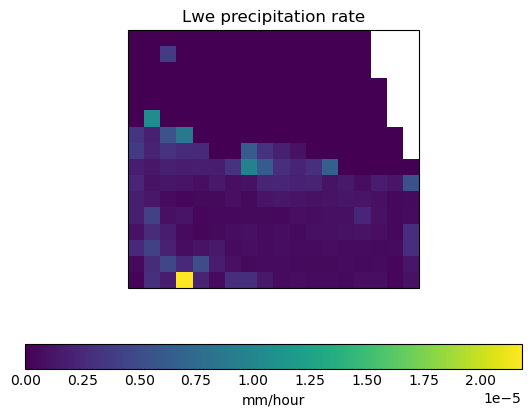

In [95]:
qplt.pcolormesh(year_cube[1,:,:])

ValueError: Data must be dict-like

/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


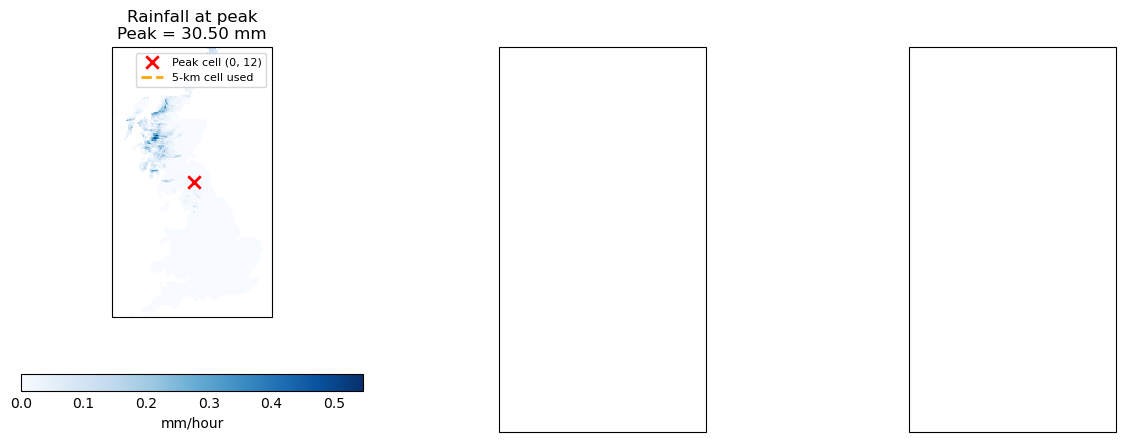

In [74]:
import cartopy.crs as ccrs
def plot_peak_soil_diagnostic(
    peak_slice,
    row,
    se_5km,
    fu_5km,
    HC_CUBE=None,
    catchment_poly=None,
    boundary_gdf=None,
    buffer=2000,
):
    """
    Diagnostic plot showing:
      1. Rainfall field at the peak timestep
      2. Saturation (Se) at the 5-km grid
      3. Fu at the 5-km grid

    The identified rainfall peak cell is marked on all panels.
    """

    # ------------------------------------------------------------
    # Peak location
    # ------------------------------------------------------------
    x_peak = row["x_coord"]
    y_peak = row["y_coord"]

    xi = int(row["x_idx"])
    yi = int(row["y_idx"])

    # ------------------------------------------------------------
    # 5-km coordinates
    # ------------------------------------------------------------
    # These should come from the HC cube because it is on the
    # same 5-km grid as se_5km and fu_5km.
    if HC_CUBE is not None:
        x5 =  hc_trimmed['projection_x_coordinate'].values
        y5 =  hc_trimmed['projection_y_coordinate'].values
#         x5 =  HC_CUBE.coord("projection_x_coordinate").points
#         y5 = HC_CUBE.coord("projection_y_coordinate").points
    else:
        raise ValueError("HC_CUBE is required to get the 5-km coordinates.")

    # Coordinates of the selected 5-km cell
    x5_peak = x5[xi]
    y5_peak = y5[yi]

    # Cell boundaries
    dx5 = np.abs(x5[1] - x5[0])
    dy5 = np.abs(y5[1] - y5[0])

    peak_5km_box = box(
        x5_peak - dx5 / 2,
        y5_peak - dy5 / 2,
        x5_peak + dx5 / 2,
        y5_peak + dy5 / 2,
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        subplot_kw={"projection": ccrs.OSGB()}
    )

    # ============================================================
    # 1. Rainfall peak
    # ============================================================
    ax = axes[0]

    qplt.pcolormesh(
        peak_slice,
        axes=ax,
        cmap="Blues"
    )

    # Mark exact rainfall peak
    ax.scatter(
        x_peak,
        y_peak,
        s=80,
        color="red",
        marker="x",
        linewidth=2,
        zorder=10,
        transform=ccrs.OSGB(),
        label=f"Peak cell ({xi}, {yi})"
    )

    # Draw the 5-km cell being sampled
    bx, by = peak_5km_box.exterior.xy
    ax.plot(
        bx,
        by,
        color="orange",
        linewidth=2,
        linestyle="--",
        transform=ccrs.OSGB(),
        label="5-km cell used"
    )

    ax.set_title(
        f"Rainfall at peak\n"
        f"Peak = {row['max_precip']:.2f} mm"
    )
    ax.legend(fontsize=8)

    # ============================================================
    # 2. Saturation
    # ============================================================
    ax = axes[1]

    # Plot the 5-km saturation array using the HC cube as the
    # coordinate/reference grid
    se_cube = HC_CUBE.copy(data=se_5km)

    qplt.pcolormesh(
        se_cube,
        axes=ax,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    ax.scatter(
        x_peak,
        y_peak,
        s=80,
        color="red",
        marker="x",
        linewidth=2,
        zorder=10,
        transform=ccrs.OSGB(),
        label="Rainfall peak"
    )

    bx, by = peak_5km_box.exterior.xy
    ax.plot(
        bx,
        by,
        color="orange",
        linewidth=2,
        linestyle="--",
        transform=ccrs.OSGB(),
        label=f"Selected cell\nSe = {se_5km[yi, xi]:.3f}"
    )

    ax.set_title("5-km saturation (Se)")
    ax.legend(fontsize=8)

    # ============================================================
    # 3. Fu
    # ============================================================
    ax = axes[2]

    fu_cube = HC_CUBE.copy(data=fu_5km)

    qplt.pcolormesh(
        fu_cube,
        axes=ax,
        cmap="Blues"
    )

    ax.scatter(
        x_peak,
        y_peak,
        s=80,
        color="red",
        marker="x",
        linewidth=2,
        zorder=10,
        transform=ccrs.OSGB(),
        label="Rainfall peak"
    )

    bx, by = peak_5km_box.exterior.xy
    ax.plot(
        bx,
        by,
        color="orange",
        linewidth=2,
        linestyle="--",
        transform=ccrs.OSGB(),
        label=f"Selected cell\nFu = {fu_5km[yi, xi]:.3f} m"
    )

    ax.set_title("5-km Fu")
    ax.legend(fontsize=8)

    # ============================================================
    # Formatting
    # ============================================================
    for ax in axes:

        if catchment_poly is not None:
            minx, miny, maxx, maxy = catchment_poly.bounds

            ax.set_extent(
                [
                    minx - buffer,
                    maxx + buffer,
                    miny - buffer,
                    maxy + buffer
                ],
                crs=ccrs.OSGB()
            )

        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(
                ax=ax,
                color="black"
            )

    plt.suptitle(
        f"Peak-cell soil-moisture diagnostic — "
        f"ens={row['ens']}, year={row['start_year']}, "
        f"event={row['event_num']}\n"
        f"Rainfall peak cell = ({xi}, {yi}) | "
        f"Se = {se_5km[yi, xi]:.3f} | "
        f"Fu = {fu_5km[yi, xi]:.3f} m",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

catchment_num   = TARGET_HA 
from config import CATCHMENTS
boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    
    
import iris.quickplot as qplt
plot_peak_soil_diagnostic(
    peak_slice=peak_slice,
    row=row,
    se_5km=se_5km,
    fu_5km=fu_5km,
    HC_CUBE=hc_trimmed,
    catchment_poly=CATCHMENT_POLY,
    boundary_gdf=boundary_gdf,
)    

In [79]:
# peak_slice = year_cube[
#     this_event_results["t_local"],
#     :, :
# ]
# peak_slice
year_cube

Lwe Precipitation Rate (mm/hour),time,projection_y_coordinate,projection_x_coordinate
Shape,18,244,180
Dimension coordinates,,,
time,x,-,-
projection_y_coordinate,-,x,-
projection_x_coordinate,-,-,x
Auxiliary coordinates,,,
month_number,x,-,-
year,x,-,-
yyyymmddhh,x,-,-
latitude,-,x,x


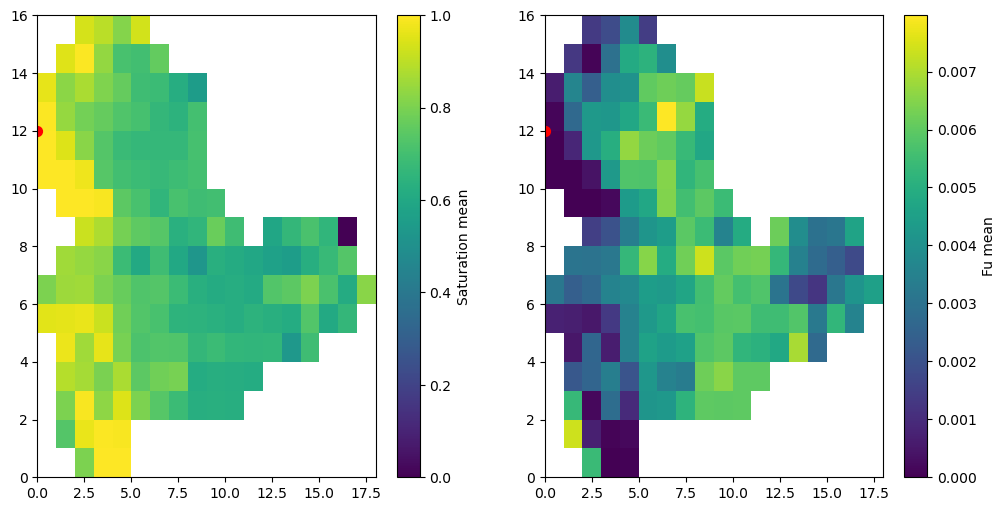

In [105]:
fig, axs = plt.subplots(ncols =2, figsize=(12, 6))
im = axs[0].pcolormesh(se_5km_da, cmap='viridis')
fig.colorbar(im, ax=axs[0], label="Saturation mean")
axs[0].scatter(row["x_idx"], row["y_idx"], s=50, c="red", marker="o")

im = axs[1].pcolormesh(fu_5km_da , cmap='viridis')
fig.colorbar(im, ax=axs[1], label="Fu mean")
axs[1].scatter(row["x_idx"], row["y_idx"], s=50, c="red", marker="o")
plt.show()

Loaded DEM for HA 23: 2855x2450
Porosity range: 0.000 to 0.434
Lu range: 0.011 to 0.067 m
Using CSV: /scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/Tyne(Northumberland)_01_full_events_with_event_nums.csv
   start_indices  stop_indices  event_durations     peaks  start_year  \
0           6177          6194               17  30.50427        1992   
1           5293          5303               10  32.84921        1994   

   start_month  start_day  start_hour  start_time  stop_time  \
0            8         18           8    195536.5   195553.5   
1            7         11          12    211932.5   211942.5   

   start_time_seconds  stop_time_seconds    event_vol  max_extent  \
0           703931400          703992600  1853.791106          73   
1           762957000          762993000   126.233498           5   

     acc_total      acc_3hr      acc_6hr     acc_12hr  acc_24hr  event_num  
0  1853.791106  1070.589100  1552.028500  1847.3

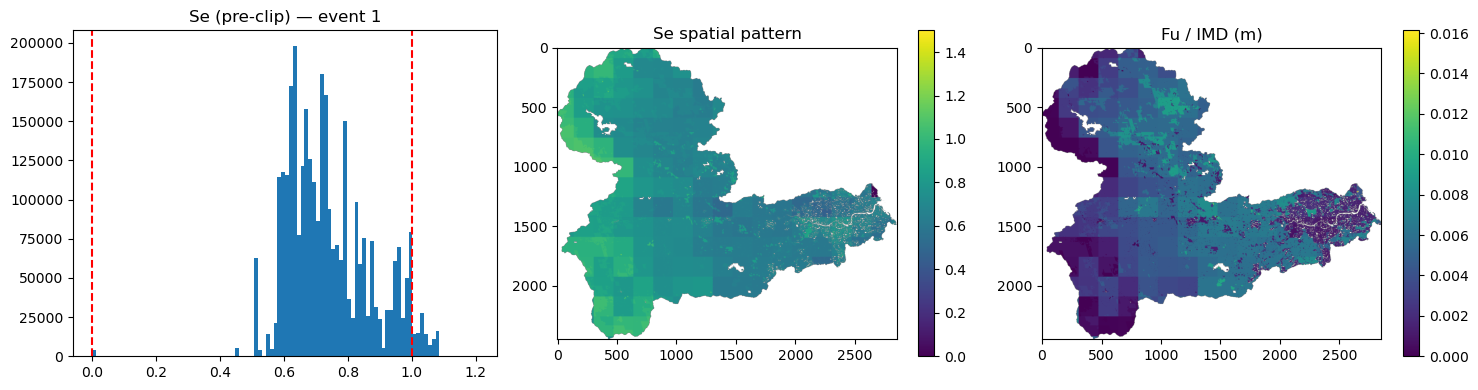


--- Event 2 (1994-07-11) ---
  Se: over1=560 (0.02%), under0=0 (0.00%), max=1.156
  Fu (m): mean=0.005, range=(0.000, 0.016)


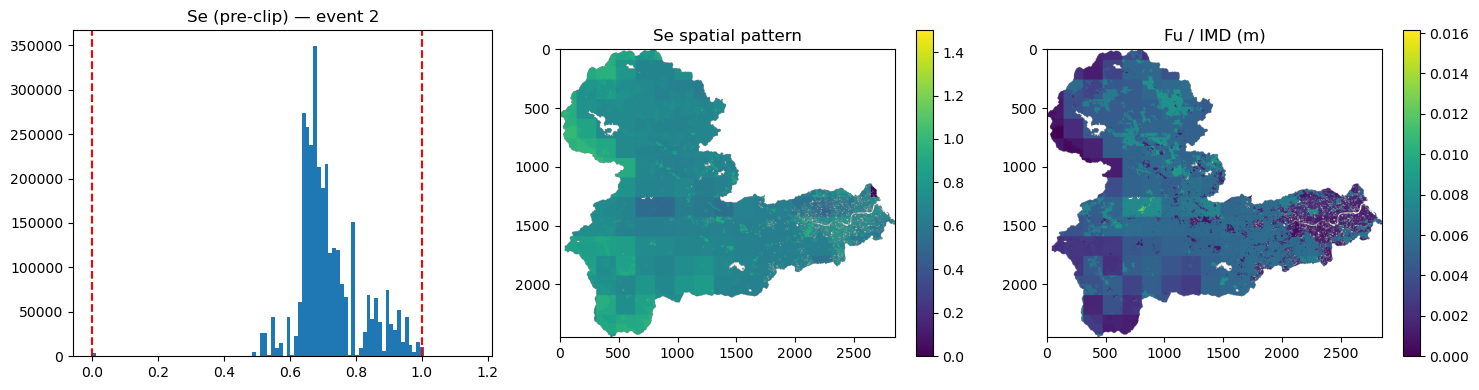


=== Summary across events ===
   event_num        date  n_valid  pct_over1  pct_under0    se_max  se_min  \
0          1  1992-08-18  3211177   3.921335         0.0  1.207047     0.0   
1          2  1994-07-11  3211177   0.017439         0.0  1.156247     0.0   

   fu_mean_m  fu_min_m  fu_max_m  
0   0.004079       0.0  0.016133  
1   0.004505       0.0  0.016133  


In [37]:
TARGET_HA = "23"        # <-- catchment to test
ENSEMBLE = "Ens_01"     # <-- ensemble member to test
N_EVENTS = 2             # <-- how many events from the matching CSV to run

target_has = {TARGET_HA}

# --------------------------
# 1. Load DEM for the target catchment
# --------------------------
dem_files = [p for p in glob.glob(os.path.join(DEM_DIR, "*.tif"))
    if extract_ha_num(p) in target_has]
if not dem_files:
    raise FileNotFoundError(f"No DEM found for HA_NUM {TARGET_HA} in {DEM_DIR}")

dem_path = dem_files[0]
ha_num = extract_ha_num(dem_path)

with rasterio.open(dem_path) as dem:
    dem_info = {
        "bounds": box(*dem.bounds),
        "transform": dem.transform,
        "crs": dem.crs,
        "width": dem.width,
        "height": dem.height,
        "mask": dem.read(1),
    }

dem_mask_bool = dem_info["mask"] == -9999
print(f"Loaded DEM for HA {ha_num}: {dem_info['width']}x{dem_info['height']}")

# --------------------------
# 2. Load porosity + Lu grids (aligned to the same soil-texture raster)
# --------------------------
soil_grids = load_soil_grids(POROSITY_CSV, SOILS_LOOKUP_CSV, SOIL_TEXTURE_DIR, target_has)
if ha_num not in soil_grids:
    raise KeyError(f"No soil-texture raster found for HA {ha_num}")

porosity_data = soil_grids[ha_num]["porosity"]
lu_data = soil_grids[ha_num]["lu"]
print(f"Porosity range: {np.nanmin(porosity_data):.3f} to {np.nanmax(porosity_data):.3f}")
print(f"Lu range: {np.nanmin(lu_data):.3f} to {np.nanmax(lu_data):.3f} m")

# --------------------------
# 3. Load the matching events CSV for this catchment
# --------------------------
gdf = load_catchments = gpd.read_file(
    "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/CEH_catchments/CEH_IHU_with_coastline/hyd_areas_GB_with_subcatchments.shp"
)
gdf["HA_NAME_NORM"] = gdf["HA_NAME"].str.replace(" ", "", regex=False)
target_catchments = gdf[gdf["HA_NUM"].astype(str).isin(target_has)]
if target_catchments.empty:
    raise ValueError(f"No catchment found for HA_NUM {TARGET_HA}")
target_names_norm = target_catchments["HA_NAME_NORM"].unique().tolist()

csv_files = [
    f for f in glob.glob(os.path.join(CSV_DIR, "*.csv"))
    if any(
        re.search(r"(^|_)" + re.escape(name) + r"(_|$)", os.path.basename(f))
        for name in target_names_norm
    )
]
if not csv_files:
    raise FileNotFoundError(f"No events CSV found for HA {TARGET_HA}")

csv_path = csv_files[0]
events_df = pd.read_csv(csv_path).head(N_EVENTS)
print(f"Using CSV: {csv_path}")
print(events_df)

# --------------------------
# 4. Run the pipeline for each event, keeping intermediate arrays
# --------------------------
results = []

for i, row in events_df.iterrows():
    year, month, day = int(row["start_year"]), int(row["start_month"]), int(row["start_day"])
    event_num = int(row["event_num"])
    start_index = int(row["start_indices"])

    nc_path = find_matching_netcdf(os.path.join(NETCDF_DIR, ENSEMBLE), year, month, day)
    if nc_path is None:
        print(f"Skipping event {event_num}: no matching NetCDF")
        continue

    with xr.open_dataset(nc_path) as ds:
        index = (start_index - 1) // 24
        grav_clipped = clip_gravitational(
            ds.isel(time=index), "moisture_content_of_soil_layer", dem_info["bounds"]
        )
        grav_30m_array = resample_to_30m_array(grav_clipped, dem_info)

    # --- degree of saturation Se = theta / theta_s (pre-clip) ---
    with np.errstate(divide="ignore", invalid="ignore"):
        vol_sm_raw = ((grav_30m_array / 1000.0) / 0.225) / porosity_data

    valid = ~dem_mask_bool & np.isfinite(vol_sm_raw)
    n_valid = int(valid.sum())
    n_over1 = int((vol_sm_raw[valid] > 1).sum()) if n_valid else 0
    n_under0 = int((vol_sm_raw[valid] < 0).sum()) if n_valid else 0

    vol_sm_clipped = np.clip(vol_sm_raw, 0, 1)

    # --- Fu / IMD (m): remaining storage capacity of the upper zone ---
    with np.errstate(divide="ignore", invalid="ignore"):
        Fu_m = lu_data * porosity_data * (1 - vol_sm_clipped)
    Fu_m[dem_mask_bool] = np.nan

    summary = {
        "event_num": event_num,
        "date": f"{year}-{month:02d}-{day:02d}",
        "n_valid": n_valid,
        "pct_over1": 100 * n_over1 / n_valid if n_valid else np.nan,
        "pct_under0": 100 * n_under0 / n_valid if n_valid else np.nan,
        "se_max": float(np.nanmax(vol_sm_raw[valid])) if n_valid else np.nan,
        "se_min": float(np.nanmin(vol_sm_raw[valid])) if n_valid else np.nan,
        "fu_mean_m": float(np.nanmean(Fu_m)),
        "fu_min_m": float(np.nanmin(Fu_m)),
        "fu_max_m": float(np.nanmax(Fu_m)),
    }
    results.append(summary)

    print(f"\n--- Event {event_num} ({summary['date']}) ---")
    print(f"  Se: over1={n_over1} ({summary['pct_over1']:.2f}%), "
          f"under0={n_under0} ({summary['pct_under0']:.2f}%), "
          f"max={summary['se_max']:.3f}")
    print(f"  Fu (m): mean={summary['fu_mean_m']:.3f}, "
          f"range=({summary['fu_min_m']:.3f}, {summary['fu_max_m']:.3f})")

    # --- plots for this event ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(vol_sm_raw[valid], bins=100)
    axes[0].axvline(0, color="red", ls="--")
    axes[0].axvline(1, color="red", ls="--")
    axes[0].set_title(f"Se (pre-clip) — event {event_num}")

    im1 = axes[1].imshow(vol_sm_raw, vmin=0, vmax=1.5)
    axes[1].set_title("Se spatial pattern")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(Fu_m, vmin=0)
    axes[2].set_title("Fu / IMD (m)")
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

# --------------------------
# 5. Summary table across events
# --------------------------
results_df = pd.DataFrame(results)
print("\n=== Summary across events ===")
print(results_df)